# LEAF TLS Processing – DE-Har

Processing pipeline for the permanent LEAF MkIII scanner at DE-Har (Hartheim), using the official `pylidar-tls-canopy` library (Armston, University of Maryland).

**Scan schedule (DE-Har 2025):**

| Scan type | Config | Schedule (local) | Shots | Duration | Primary use |
|---|---|---|---|---|---|
| hinge-hi | scan1 | 6×/day | 42,500 (5 rings × 8,500 az) | ~5 min | PAI time series (57.5° hinge) |
| hemi-low | scan2 | 8×/day | 14,600 (100 az × 146 zen) | ~6 min | Fast Pgap hemisphere |
| hemi-hi | scan4 | 8×/day | 233,600 (400 az × 584 zen) | ~42 min | High-res PAVD profiles, 3D structure |

**Key references:**
- Jupp et al. (2009) *Tree Physiology* – LAI profiles from ground-based laser
- Calders et al. (2014) *Sensors* – Automated LEAF monitoring
- Culvenor et al. (2014) *Sensors* – LEAF instrument and rain/wind effects

In [76]:
import os
import glob
import time
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

from pylidar_tls_canopy import leaf_io, plant_profile, grid, visualize
from pylidar_tls_canopy.rsmooth import rsmooth

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

## 1. Settings

Adjust these parameters for the DE-Har deployment.

In [77]:
# --- Site and instrument ---
SENSOR_ID = 320               # LEAF serial (ESS00320)
SENSOR_HEIGHT = 1.5           # Height of LEAF sensor head above ground (m)
ZENITH_OFFSET = 0             # Fixed zenith offset (rad)

# --- Profile parameters ---
HRES = 0.5                    # Vertical bin size (m) for PAVD profiles
MAX_H = 25                    # Maximum height (m) — canopy tops ~19m, with buffer
MIN_ZENITH = 5                # Minimum zenith angle (deg) — exclude near-vertical
MAX_ZENITH = 70               # Maximum zenith angle (deg) — exclude near-horizon
ZRES = 5                      # Zenith bin size (deg) for Pgap aggregation
ARES = 45                     # Azimuth bin size (deg) for Pgap aggregation — 8 sectors

# --- Target weighting method ---
# FIRSTLAST: each return gets weight 0.5 (recommended for LEAF first+last return data)
# WEIGHTED: weight = 1/target_count
# FIRST: first returns only
METHOD = 'FIRSTLAST'

# --- Data paths ---
PROJECT_ROOT = Path().resolve().parents[1]
DATA_DIR = PROJECT_ROOT / "data" / "raw" / "proximal_rs" / "leaf"

# Derived
NBINS = int(MAX_H / HRES)

## 2. Discover scan files

In [78]:
hemi_hi_files  = sorted(DATA_DIR.glob('ESS?????_*_hemi_*_0800_0400.csv'))
hemi_low_files = sorted(DATA_DIR.glob('ESS?????_*_hemi_*_0200_0100.csv'))
hinge_files    = sorted(DATA_DIR.glob('ESS?????_*_hinge_*.csv'))

print(f'Hemi-hi:  {len(hemi_hi_files)} files')
print(f'Hemi-low: {len(hemi_low_files)} files')
print(f'Hinge:    {len(hinge_files)} files')

if hemi_hi_files:
    print(f'Date range: {hemi_hi_files[0].name} → {hemi_hi_files[-1].name}')

Hemi-hi:  1940 files
Hemi-low: 1939 files
Hinge:    1459 files
Date range: ESS00320_0013_hemi_20250416-201030Z_0800_0400.csv → ESS00320_5348_hemi_20251215-081031Z_0800_0400.csv


## 3. Inspect a single scan

Load a scan using `leaf_io.LeafScanFile` to verify geometry and data quality.

In [72]:
# Pick example files (adjust indices as needed)
example_hemi = str(hemi_hi_files[500]) if hemi_hi_files else None
example_hinge = str(hinge_files[500]) if hinge_files else None

if example_hemi:
    f = leaf_io.LeafScanFile(example_hemi, sensor_height=SENSOR_HEIGHT,
                              zenith_offset=ZENITH_OFFSET)
    print(f'Scan type:  {f.scan_type}')
    print(f'Datetime:   {f.datetime}')
    print(f'Resolution: {f.zenith_shots} zen × {f.azimuth_shots} az')
    print(f'Firmware:   {f.header.get("Firmware ver.", "?")}')
    print(f'Tilt (raw): {f.header.get("Tilt", "?")}')
    print(f'Encl. temp: {f.header.get("Encl. Temp", "?")} C')
    print(f'Encl. RH:   {f.header.get("Encl. humidity", "?")} %')
    print(f'N samples:  {len(f.data)}')
    print(f'\nZenith range: {np.degrees(f.data.zenith.min()):.1f}° – '
          f'{np.degrees(f.data.zenith.max()):.1f}°')
    print(f'Azimuth range: {np.degrees(f.data.azimuth.min()):.1f}° – '
          f'{np.degrees(f.data.azimuth.max()):.1f}°')
    display(f.data.head())

Scan type:  hemi
Datetime:   2025-06-18 08:10:30
Resolution: 800 zen × 400 az
Firmware:   4.53
Tilt (raw): (26.48, -24.06, 1051.16)
Encl. temp: 22.8 C
Encl. RH:   19.9 %
N samples:  234184

Zenith range: 0.0° – 133.6°
Azimuth range: 0.4° – 360.0°


,sample_count,scan_encoder,rotary_encoder,range1,intensity1,range2,intensity2,sample_time,target_count,datetime,zenith,azimuth,x1,y1,z1,h1,x2,y2,z2,h2
0,108,3488.0,0,0.37,100,0.37,100,4.68,2,2025-06-18 08:10:30.004680,2.251485,5.449941,-0.212814,0.193365,-0.232851,1.267149,-0.212814,0.193365,-0.232851,1.267149
1,109,3520.0,0,0.38,100,0.38,100,4.46,2,2025-06-18 08:10:30.009140,2.243631,5.449941,-0.219950,0.199848,-0.236818,1.263182,-0.219950,0.199848,-0.236818,1.263182
2,110,3552.0,0,0.54,100,0.54,100,4.48,2,2025-06-18 08:10:30.013620,2.235777,5.449941,-0.314506,0.285764,-0.333204,1.166796,-0.314506,0.285764,-0.333204,1.166796
3,111,3584.0,0,0.70,100,0.70,100,4.48,2,2025-06-18 08:10:30.018100,2.227923,5.449941,-0.410192,0.372704,-0.427591,1.072409,-0.410192,0.372704,-0.427591,1.072409
4,112,3616.0,0,0.81,100,0.81,100,4.47,2,2025-06-18 08:10:30.022570,2.220069,5.449941,-0.477512,0.433872,-0.489732,1.010268,-0.477512,0.433872,-0.489732,1.010268


### 3.1 Hemispherical projection (range grid)

Grid the scan onto a spherical (zenith × azimuth) grid using `grid.grid_leaf_spherical`. This is the visual equivalent of a hemispherical photograph — useful for identifying canopy gaps, the understory/overstory separation, and instrument issues.

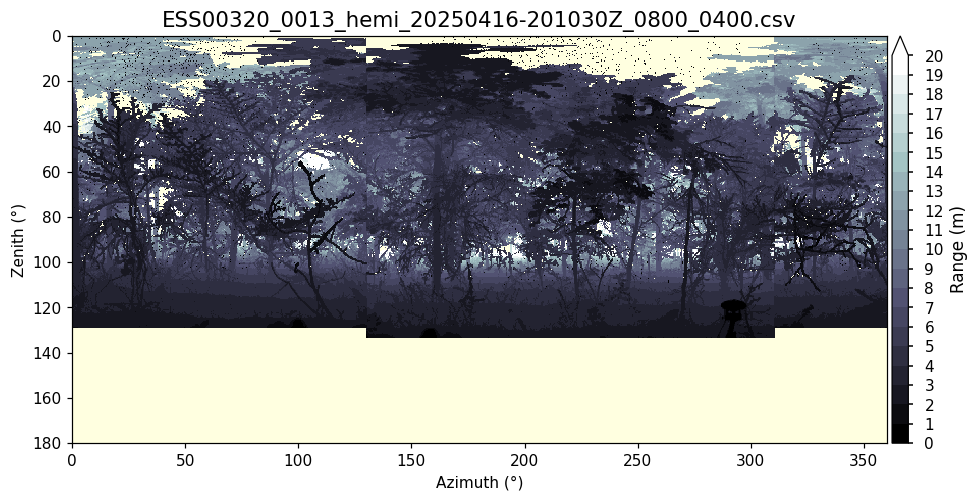

In [10]:
if example_hemi:
    # Resolution should match the scan step: 0.45° for hemi-hi, 1.8° for hemi-low
    resolution = 0.45
    
    leaf_range_grid = grid.grid_leaf_spherical(
        example_hemi, resolution, attribute='range1',
        method='MIN', sensor_height=SENSOR_HEIGHT,
        zenith_offset=ZENITH_OFFSET)
    
    visualize.plot_leaf_grid(
        leaf_range_grid, label='Range (m)', clim=[0, 20],
        figsize=(9, 7), nbins=20, cmap='bone',
        extent=[0, 360, 180, 0],
        xlabel='Azimuth (°)', ylabel='Zenith (°)',
        facecolor='lightyellow',
        title=os.path.basename(example_hemi))

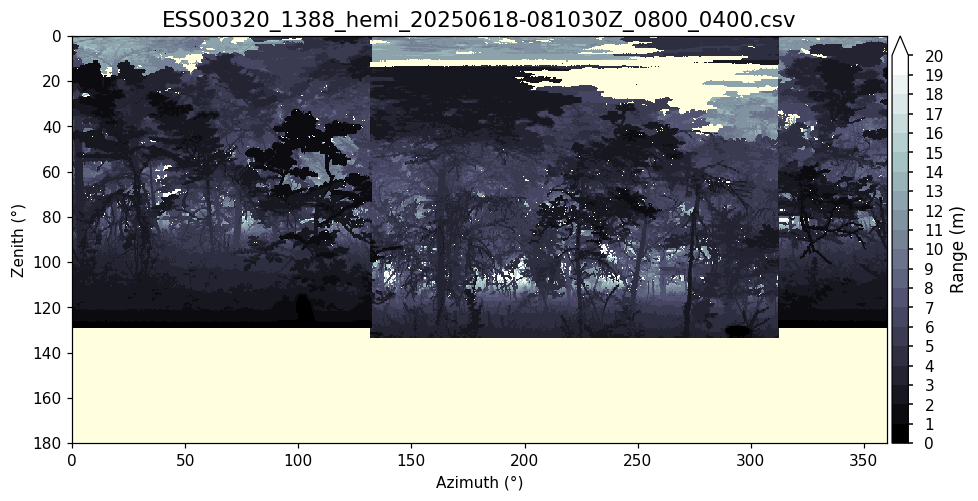

In [7]:
if example_hemi:
    # Resolution should match the scan step: 0.45° for hemi-hi, 1.8° for hemi-low
    resolution = 0.45
    
    leaf_range_grid = grid.grid_leaf_spherical(
        example_hemi, resolution, attribute='range1',
        method='MIN', sensor_height=SENSOR_HEIGHT,
        zenith_offset=ZENITH_OFFSET)
    
    visualize.plot_leaf_grid(
        leaf_range_grid, label='Range (m)', clim=[0, 20],
        figsize=(9, 7), nbins=20, cmap='bone',
        extent=[0, 360, 180, 0],
        xlabel='Azimuth (°)', ylabel='Zenith (°)',
        facecolor='lightyellow',
        title=os.path.basename(example_hemi))

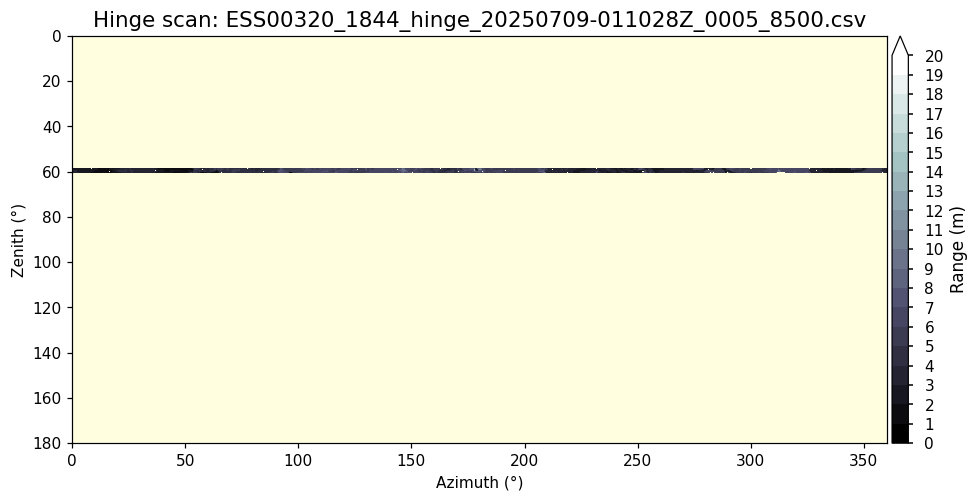

In [8]:
# Also check the hinge scan footprint
if example_hinge:
    leaf_hinge_grid = grid.grid_leaf_spherical(
        example_hinge, 0.45, attribute='range1',
        method='MIN', sensor_height=SENSOR_HEIGHT,
        zenith_offset=ZENITH_OFFSET)
    
    visualize.plot_leaf_grid(
        leaf_hinge_grid, label='Range (m)', clim=[0, 20],
        figsize=(9, 7), nbins=20, cmap='bone',
        extent=[0, 360, 180, 0],
        xlabel='Azimuth (°)', ylabel='Zenith (°)',
        facecolor='lightyellow',
        title=f'Hinge scan: {os.path.basename(example_hinge)}')

---
## 4. Pgap and vertical profiles – single scan

Use the `Jupp2009` class from `plant_profile` to compute:
- Gap fraction profiles Pgap(θ, z)
- PAI(z) via three methods: Hinge, Linear, Solid-angle-weighted
- PAVD(z) as the vertical derivative of PAI(z)

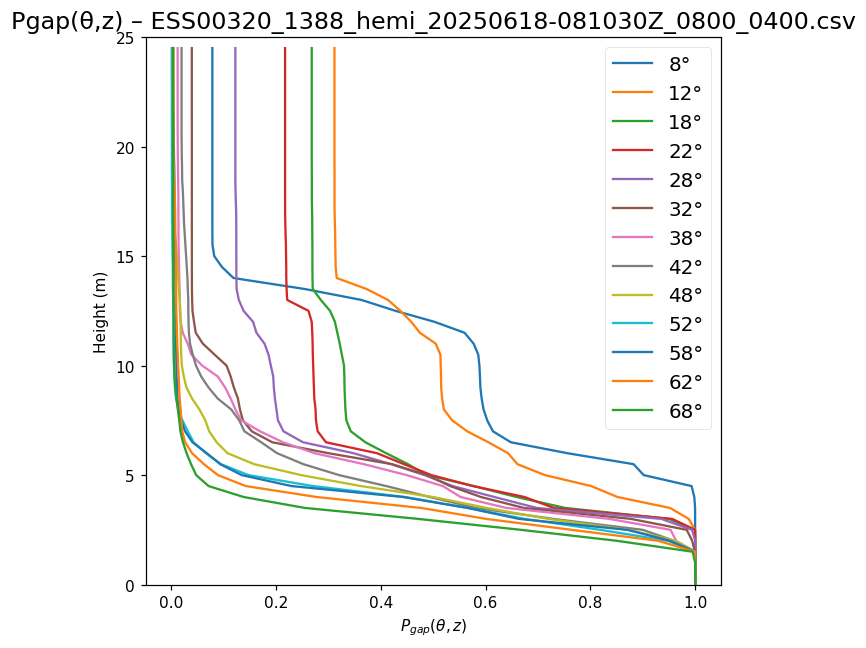

In [73]:
if example_hemi:
    vpp = plant_profile.Jupp2009(
        hres=HRES, zres=ZRES, ares=ARES,
        min_z=MIN_ZENITH, max_z=MAX_ZENITH,
        min_h=0, max_h=MAX_H)
    
    valid = vpp.add_leaf_scan_position(
        example_hemi, method=METHOD,
        min_zenith=MIN_ZENITH, max_zenith=MAX_ZENITH,
        sensor_height=SENSOR_HEIGHT,
        zenith_offset=ZENITH_OFFSET)
    
    if valid:
        vpp.get_pgap_theta_z()
        
        # Plot Pgap profiles by zenith ring
        pgap_labels = [f'{b:.0f}°' for b in vpp.zenith_bin]
        visualize.plot_vertical_profiles(
            vpp.pgap_theta_z, vpp.height_bin,
            labels=pgap_labels,
            title=f'Pgap(θ,z) – {os.path.basename(example_hemi)}',
            ylim=(0, MAX_H),
            xlabel=r'$P_{gap}(\theta, z)$')
    else:
        print('No valid data in scan')

,Height,HingePAI,LinearPAI,LinearMLA,WeightedPAI,HingePAVD,LinearPAVD,WeightedPAVD
0,0.0,-0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.5,-0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,1.0,-0.000000,0.000000,0.000000,0.000000,0.000124,0.000579,0.000956
3,1.5,0.000124,0.000579,90.000000,0.000956,0.054159,0.037969,0.056981
4,2.0,0.054159,0.037969,90.000000,0.056981,0.152117,0.107226,0.161873
5,2.5,0.152241,0.107805,90.000000,0.162829,0.396548,0.285568,0.346191
6,3.0,0.450708,0.323537,90.000000,0.403172,0.474137,0.650324,0.662245
7,3.5,0.626379,0.758129,86.282516,0.825074,0.445444,0.792927,0.785054
8,4.0,0.896151,1.116464,88.287338,1.188227,0.992676,0.826739,0.839829
9,4.5,1.619054,1.584868,90.000000,1.664903,1.309547,0.894000,0.918641


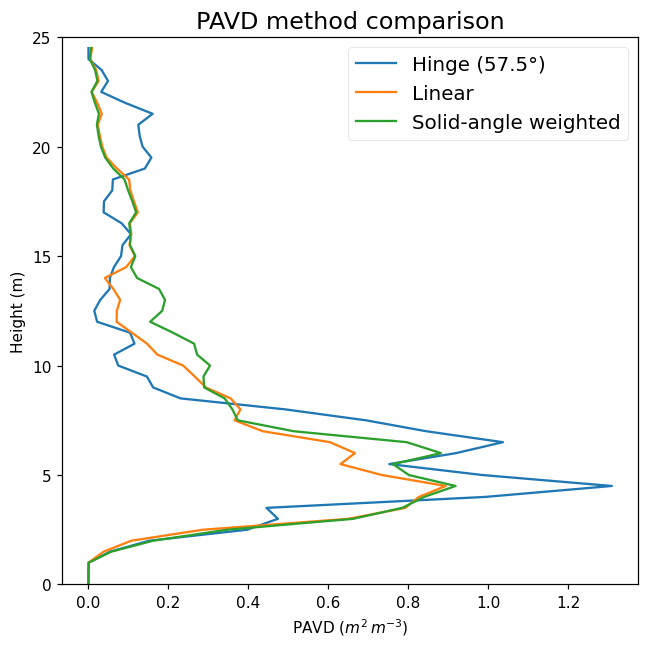

HingePAI: 6.14
LinearPAI: 5.30
WeightedPAI: 6.14


In [74]:
if example_hemi and valid:
    # Export all profile methods
    profiles_df = vpp.exportPlantProfiles()
    display(profiles_df.head(10))
    
    # Plot PAVD comparison: Hinge vs Linear vs Weighted
    visualize.plot_vertical_profiles(
        [profiles_df['HingePAVD'].values,
         profiles_df['LinearPAVD'].values,
         profiles_df['WeightedPAVD'].values],
        profiles_df['Height'].values,
        labels=['Hinge (57.5°)', 'Linear', 'Solid-angle weighted'],
        title='PAVD method comparison',
        ylim=(0, MAX_H),
        xlabel=r'PAVD ($m^2\,m^{-3}$)')
    
    # Total PAI
    for col in ['HingePAI', 'LinearPAI', 'WeightedPAI']:
        print(f'{col}: {profiles_df[col].max():.2f}')

### 4.1 Hinge scan vs hemi scan comparison

Check whether hinge-only and hemi-derived profiles agree at the 57.5° ring.

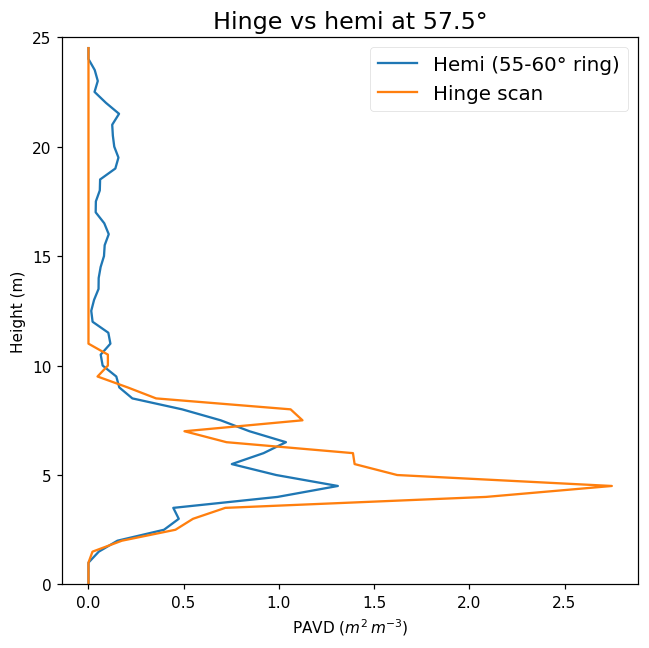

In [75]:
if example_hemi and example_hinge:
    # Hemi – extract only the 55-60° zenith ring (≈ hinge angle)
    hemi_vpp = plant_profile.Jupp2009(
        hres=HRES, zres=ZRES, ares=ARES,
        min_z=55, max_z=60, min_h=0, max_h=MAX_H)
    hemi_valid = hemi_vpp.add_leaf_scan_position(
        example_hemi, method=METHOD,
        min_zenith=55, max_zenith=60,
        sensor_height=SENSOR_HEIGHT,
        zenith_offset=ZENITH_OFFSET)
    if hemi_valid:
        hemi_vpp.get_pgap_theta_z()
        hemi_pai = hemi_vpp.calcHingePlantProfiles()
        hemi_pavd = hemi_vpp.get_pavd(hemi_pai)
    
    # Hinge scan
    hinge_vpp = plant_profile.Jupp2009(
        hres=HRES, zres=ZRES, ares=ARES,
        min_z=55, max_z=60, min_h=0, max_h=MAX_H)
    hinge_valid = hinge_vpp.add_leaf_scan_position(
        example_hinge, method=METHOD,
        min_zenith=55, max_zenith=60,
        sensor_height=SENSOR_HEIGHT,
        zenith_offset=ZENITH_OFFSET)
    if hinge_valid:
        hinge_vpp.get_pgap_theta_z()
        hinge_pai = hinge_vpp.calcHingePlantProfiles()
        hinge_pavd = hinge_vpp.get_pavd(hinge_pai)
    
    if hemi_valid and hinge_valid:
        visualize.plot_vertical_profiles(
            [hemi_pavd, hinge_pavd],
            hemi_vpp.height_bin,
            labels=['Hemi (55-60° ring)', 'Hinge scan'],
            title='Hinge vs hemi at 57.5°',
            ylim=(0, MAX_H),
            xlabel=r'PAVD ($m^2\,m^{-3}$)')

---
## 5. Batch processing – hinge scan time series

Process all hinge scans to build a PAI/PAVD time series. Hinge scans are fast (5 min) and give robust PAI at 57.5° — ideal for the drought cascade timeline.

In [24]:
len(hemi_hi_files)

1940

In [21]:
from multiprocessing import Pool
import os

def _process_leaf_worker(args):
    """Process a single LEAF file → Jupp2009 object or None."""
    filepath, jupp_kw, leaf_kw = args
    from pylidar_tls_canopy import plant_profile as pp
    vpp = pp.Jupp2009(**jupp_kw)
    try:
        if vpp.add_leaf_scan_position(filepath, **leaf_kw):
            vpp.get_pgap_theta_z()
            return vpp
    except Exception:
        pass
    return None

jupp_kw = dict(hres=HRES, zres=ZRES, ares=ARES,
               min_z=MIN_ZENITH, max_z=MAX_ZENITH, min_h=0, max_h=MAX_H)
leaf_kw = dict(method=METHOD, min_zenith=MIN_ZENITH, max_zenith=MAX_ZENITH,
               sensor_height=SENSOR_HEIGHT, zenith_offset=ZENITH_OFFSET)
tasks = [(str(f), jupp_kw, leaf_kw) for f in hemi_hi_files]

n_workers = min(32, os.cpu_count() or 4)
t0 = time.time()

with Pool(n_workers) as pool:
    leaf_hinge_vpp = []
    for i, result in enumerate(pool.imap(_process_leaf_worker, tasks, chunksize=16)):
        leaf_hinge_vpp.append(result)
        done = i + 1
        if done % 200 == 0 or done == len(tasks):
            n_ok = sum(v is not None for v in leaf_hinge_vpp)
            print(f'  {done}/{len(tasks)} processed, '
                  f'{n_ok} valid ({time.time()-t0:.0f}s)')

leaf_hinge_meta = []
n_valid = sum(v is not None for v in leaf_hinge_vpp)
print(f'Done: {n_valid}/{len(hemi_hi_files)} valid '
      f'in {time.time()-t0:.0f}s ({n_workers} workers)')

  200/1940 processed, 200 valid (7s)
  400/1940 processed, 400 valid (7s)
  600/1940 processed, 600 valid (13s)
  800/1940 processed, 800 valid (13s)
  1000/1940 processed, 1000 valid (14s)
  1200/1940 processed, 1200 valid (19s)
  1400/1940 processed, 1400 valid (20s)
  1600/1940 processed, 1600 valid (25s)
  1800/1940 processed, 1800 valid (25s)
  1940/1940 processed, 1940 valid (25s)
Done: 1940/1940 valid in 26s (32 workers)


### 5.1 Build regular daily time series

In [22]:
# Filter to valid entries
valid_vpp = [v for v in leaf_hinge_vpp if v is not None]
if not valid_vpp:
    raise RuntimeError('No valid scans processed')

ndays = (valid_vpp[-1].datetime - valid_vpp[0].datetime).days + 1
leaf_dates = np.array([valid_vpp[0].datetime + datetime.timedelta(days=d)
                       for d in range(ndays)])

# Identify scan hours with >1 observation (multiple per day)
scan_hours_all = [v.datetime.hour for v in valid_vpp]
scan_hours, scan_count = np.unique(scan_hours_all, return_counts=True)
scan_hours = [h for h, c in zip(scan_hours, scan_count) if c > 1]
print(f'Scan hours with repeat coverage: {scan_hours}')
print(f'Date range: {leaf_dates[0]} to {leaf_dates[-1]} ({ndays} days)')

# Build PAI(z) grids per scan hour
pai_z_grids = []
for scan_hour in scan_hours:
    with grid.LidarGrid(ndays, NBINS, 0, NBINS, resolution=1,
                         init_cntgrid=True) as grd:
        for vpp in valid_vpp:
            if vpp.datetime.hour == scan_hour:
                day = (vpp.datetime - valid_vpp[0].datetime).days
                pai_z = vpp.calcHingePlantProfiles()
                grd.add_column(pai_z, xidx=day, zidx=0)
        grd.finalize_grid(method='MEAN')
        pai_z_grids.append(grd.get_grid())

Scan hours with repeat coverage: [np.int64(2), np.int64(5), np.int64(8), np.int64(11), np.int64(14), np.int64(17), np.int64(20), np.int64(23)]
Date range: 2025-04-16 20:10:30 to 2025-12-14 20:10:30 (243 days)


### 5.2 Quality filtering via robust smoothing

Following Garcia (2010) — identifies outliers caused by rain, wind, or other perturbations.

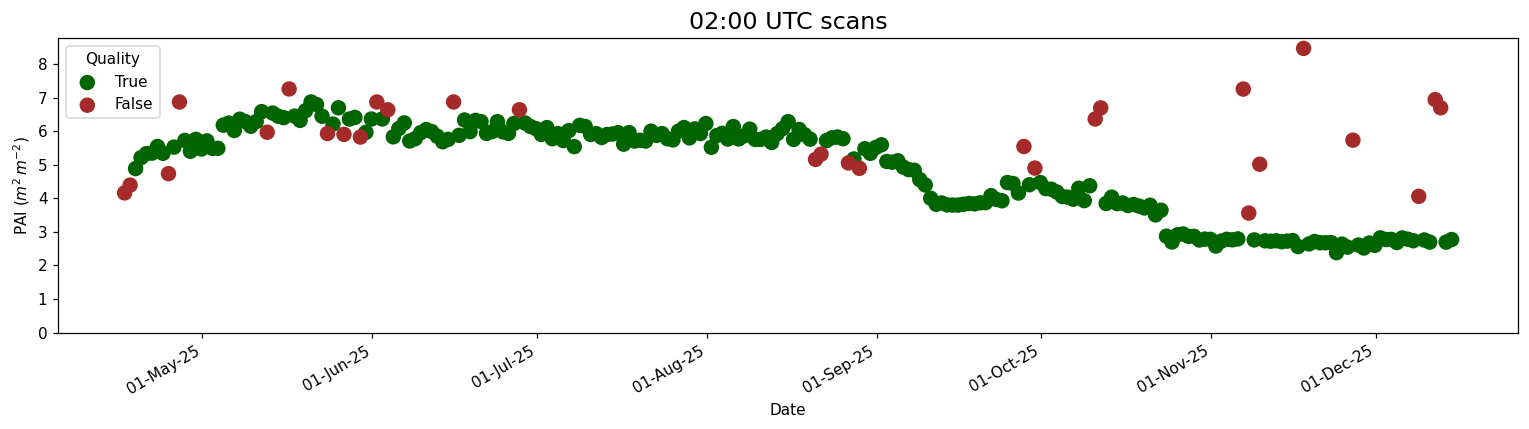

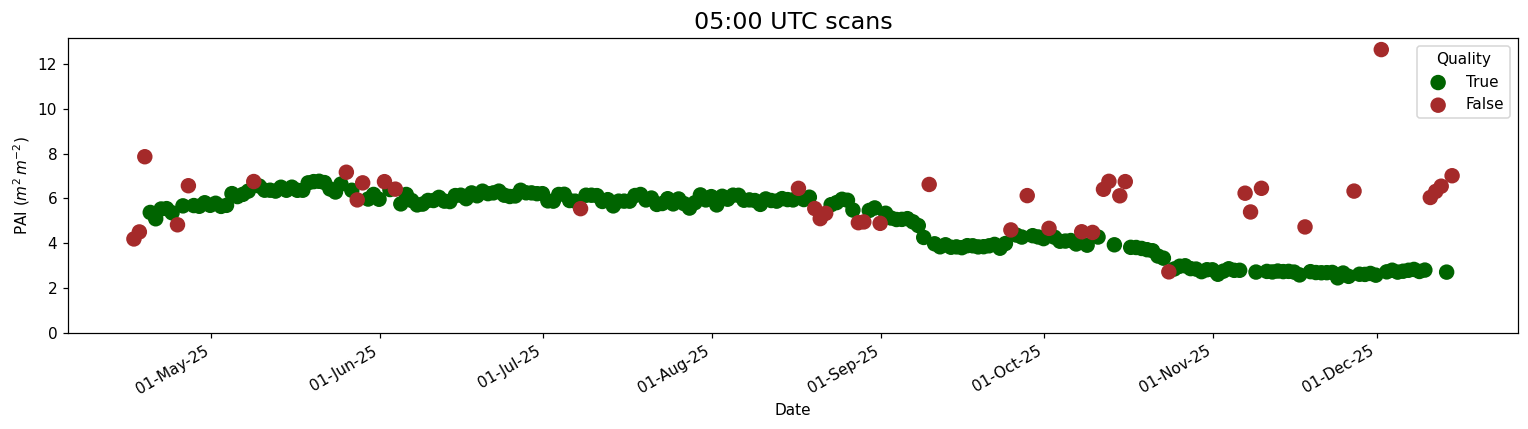

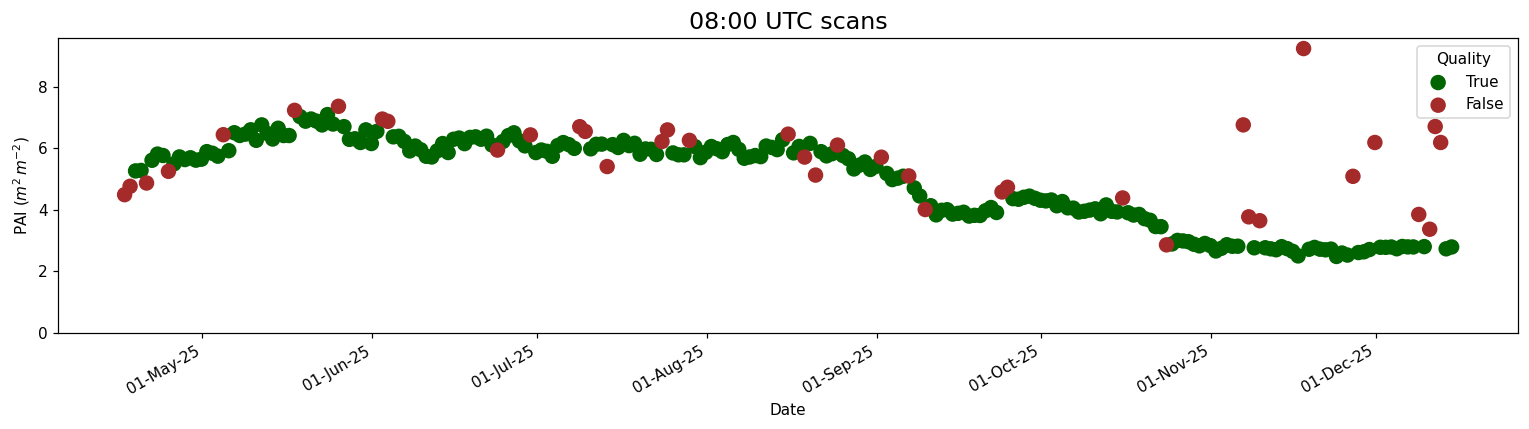

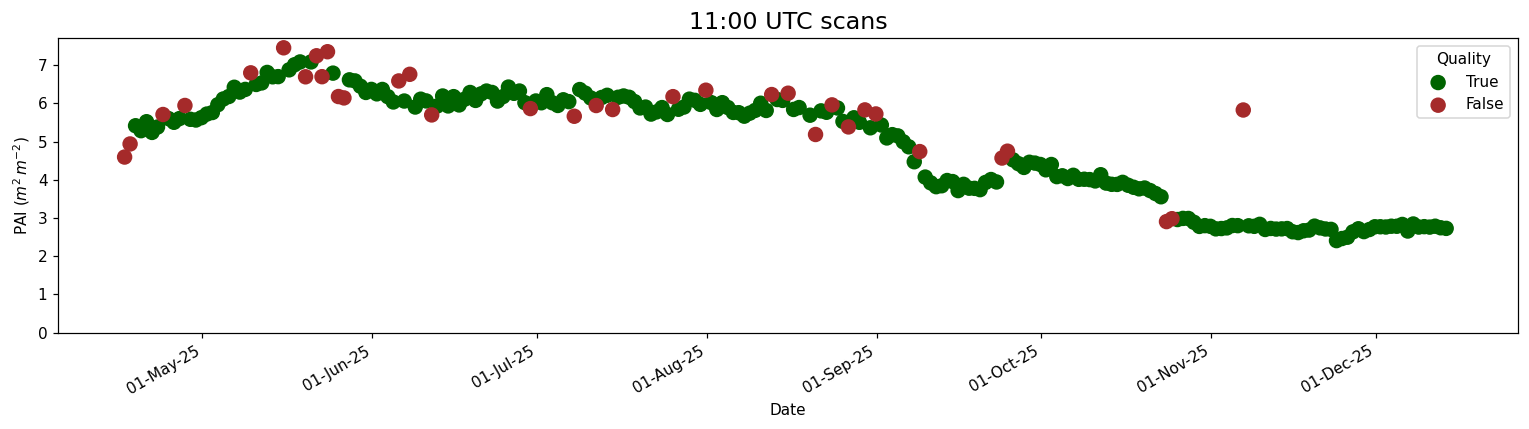

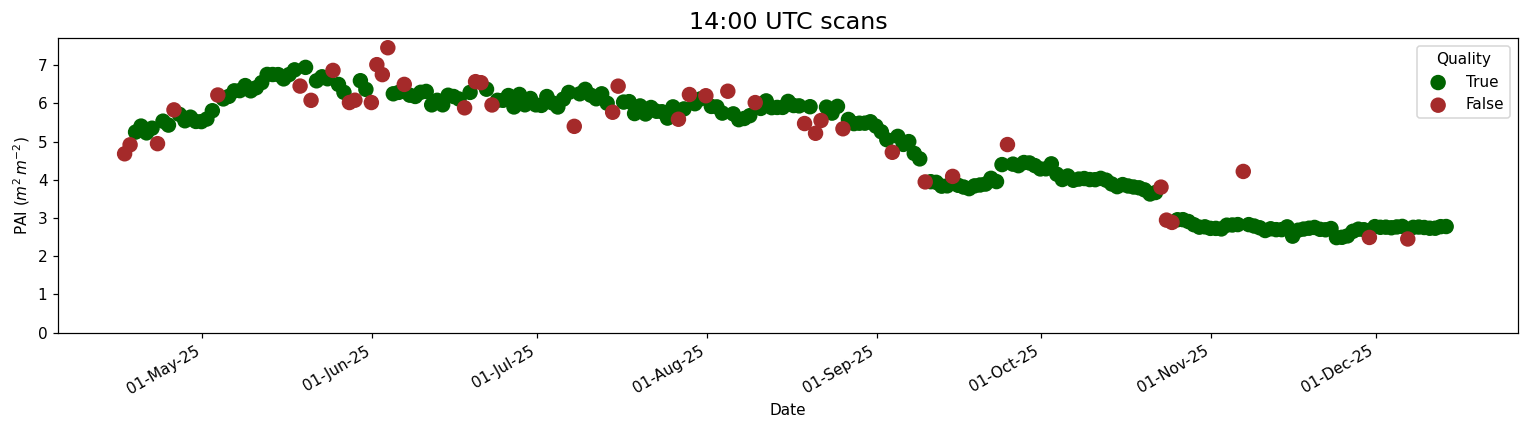

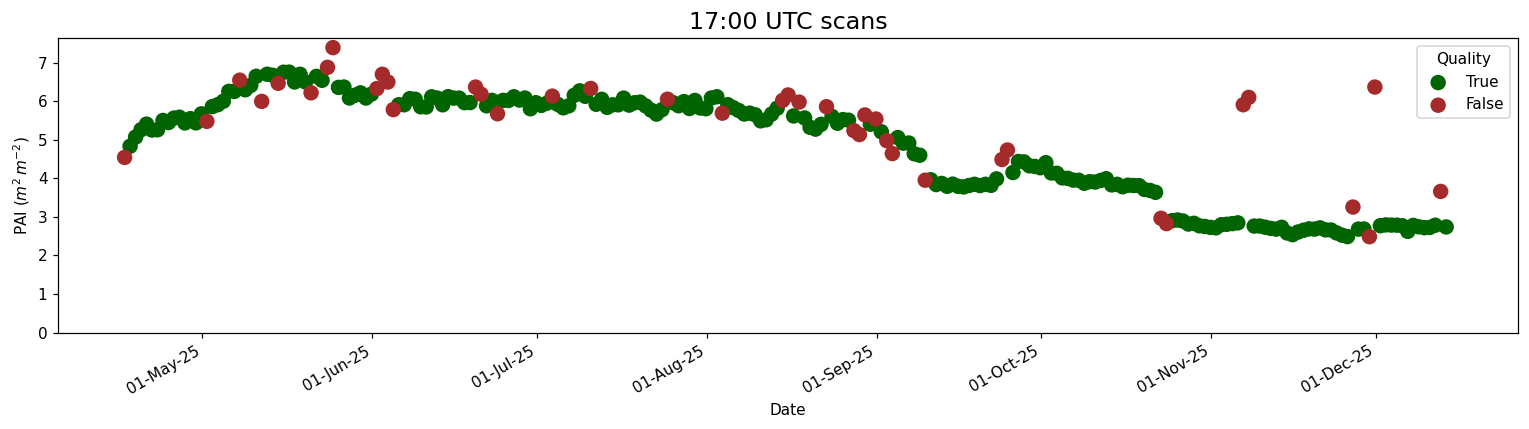

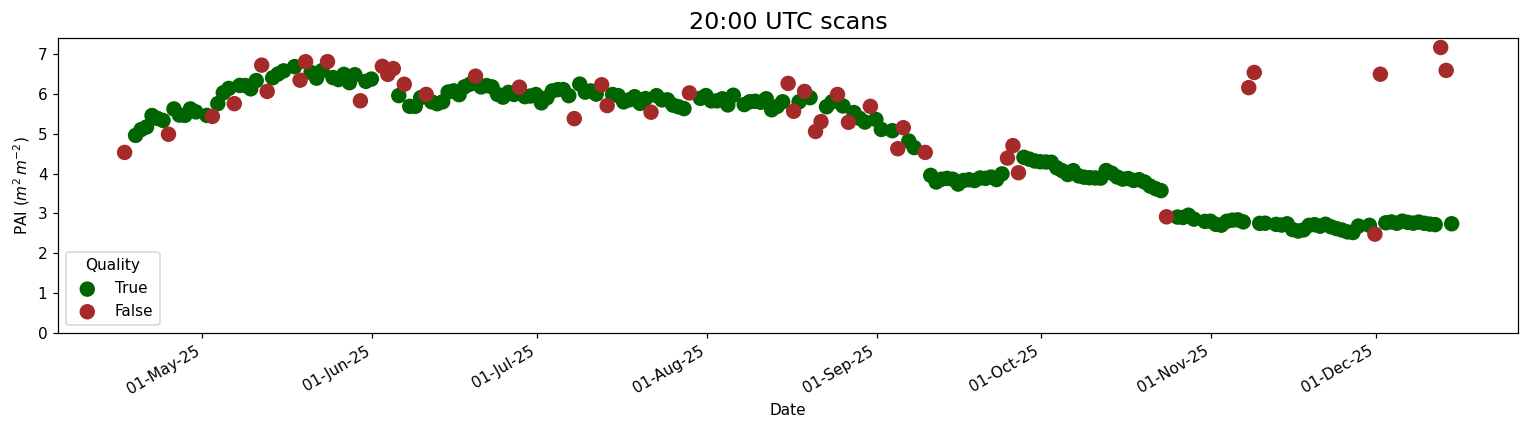

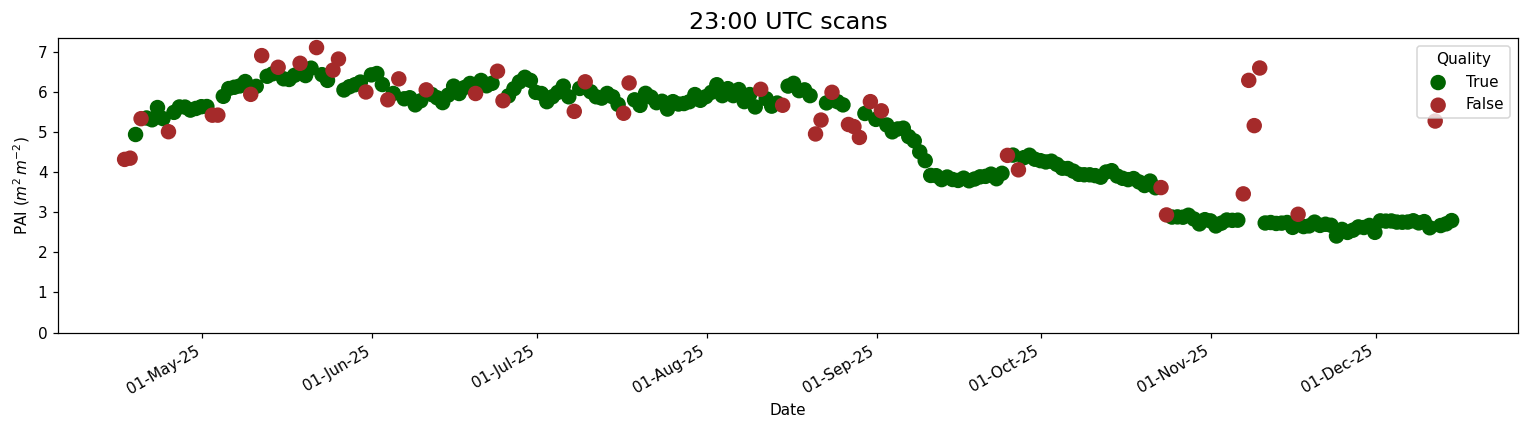

In [27]:
pai_ts = []
pai_smooth_ts = []
quality_flags = []

for pai_z_grid in pai_z_grids:
    # Total PAI = maximum of cumulative PAI profile
    pai_z0 = np.nanmax(pai_z_grid[0, :, :], axis=0)
    pai_z0[pai_z0 == -9999] = np.nan
    
    # Robust smoothing
    y = pai_z0.copy()
    z_smooth, w = rsmooth(y)
    
    # Flag outliers: low weight from robust smoother
    good = (w > 0.5) & ~np.isnan(pai_z0)
    
    pai_ts.append(pai_z0)
    pai_smooth_ts.append(z_smooth)
    quality_flags.append(good)

# Plot PAI time series per scan hour
for i, scan_hour in enumerate(scan_hours):
    title = f'{scan_hour:02d}:00 UTC scans'
    visualize.plot_timseries_1d(
        leaf_dates, pai_ts[i], quality_flags[i],
        fitted=pai_smooth_ts[i],
        ylim=[0, None], title=title,
        ylabel=r'PAI ($m^{2}\,m^{-2}$)',
        linestyle='',
        figsize=(14, 4))

---
## 6. PAVD time series – heatmap

The 2D heatmap (time × height) is the key product: it shows how canopy density changes vertically through the season, revealing differential responses between the pine overstory (14–19 m) and deciduous understory (2–10 m).

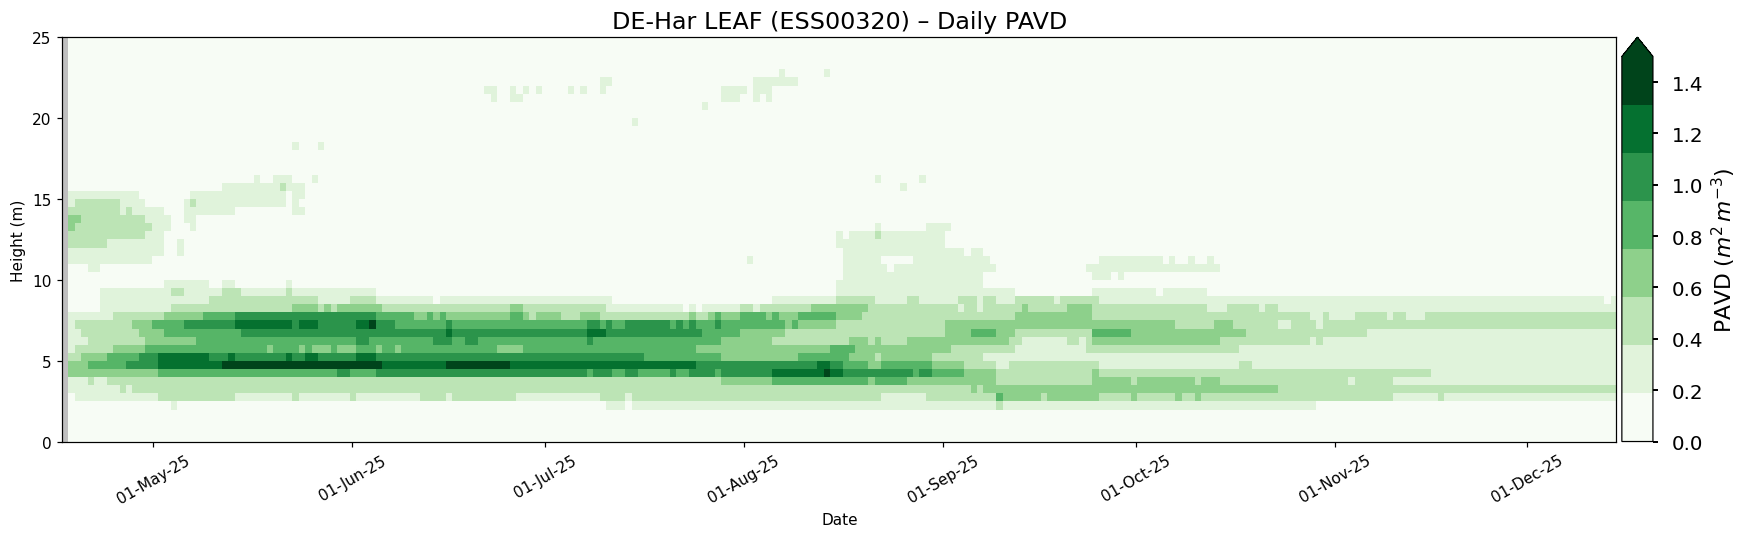

In [71]:
# Build daily PAVD grid using quality-filtered scans
with grid.LidarGrid(ndays, NBINS, 0, NBINS, resolution=1,
                     init_cntgrid=True) as grd:
    for vpp in valid_vpp:
        d = vpp.datetime
        day = (d - valid_vpp[0].datetime).days
        if d.hour in scan_hours:
            scan_idx = scan_hours.index(d.hour)
            if quality_flags[scan_idx][day]:
                pai_z = vpp.calcHingePlantProfiles()
                pavd = vpp.get_pavd(pai_z)
                grd.add_column(pavd, xidx=day, zidx=0)
    grd.finalize_grid(method='MEAN')
    pavd_grid = grd.get_grid()

xextent = [leaf_dates[0], leaf_dates[-1]]
yextent = [0, MAX_H]
pavd_grid_masked = np.ma.masked_equal(pavd_grid, -9999)

visualize.plot_timseries_2d(
    pavd_grid_masked[0, ::-1, :],
    clim=[0, 1.5],
    title=f'DE-Har LEAF (ESS00{SENSOR_ID}) – Daily PAVD',
    nbins=8, cmap='Greens',
    label=r'PAVD ($m^{2}\,m^{-3}$)',
    facecolor='0.75', extend='max',
    xextent=xextent, yextent=yextent,
    figsize=(16, 5), xrotation=30)

### 6.1 Height-integrated PAI by canopy layer

For the SPAC cascade analysis: separate time series for the pine overstory and deciduous understory.

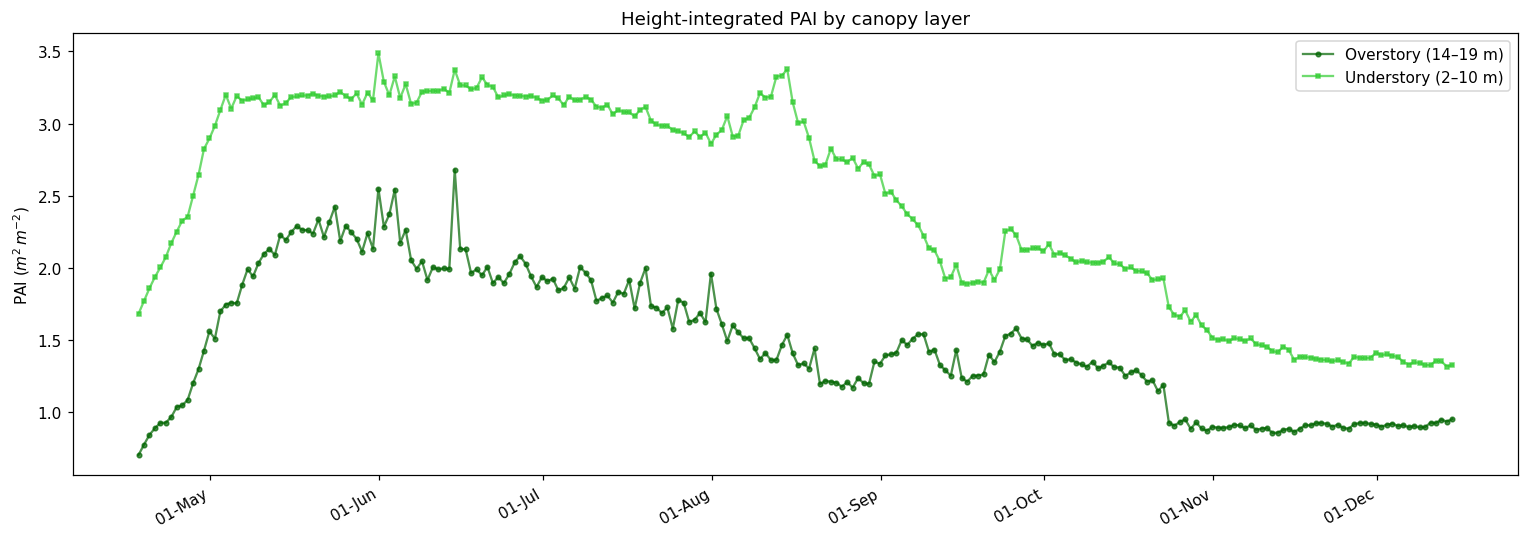

In [67]:
# Height layer definitions (in bin indices)
understory_bins = (vpp.height_bin >= 1) & (vpp.height_bin <= 6)
overstory_bins  = (vpp.height_bin >= 6) & (vpp.height_bin <= 8)

pai_understory = np.full(ndays, np.nan)
pai_overstory = np.full(ndays, np.nan)

for vpp_i in valid_vpp:
    d = vpp_i.datetime
    day = (d - valid_vpp[0].datetime).days
    if d.hour in scan_hours:
        scan_idx = scan_hours.index(d.hour)
        if quality_flags[scan_idx][day]:
            pai_z = vpp_i.calcHingePlantProfiles()
            pavd = vpp_i.get_pavd(pai_z)
            pai_understory[day] = np.sum(pavd[understory_bins]) * HRES
            pai_overstory[day] = np.sum(pavd[overstory_bins]) * HRES

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(leaf_dates, pai_overstory, 'o-', ms=3, color='darkgreen',
        alpha=0.7, label='Overstory (14–19 m)')
ax.plot(leaf_dates, pai_understory, 's-', ms=3, color='limegreen',
        alpha=0.7, label='Understory (2–10 m)')
ax.set(ylabel=r'PAI ($m^2\,m^{-2}$)', title='Height-integrated PAI by canopy layer')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### 6.2 Diurnal PAI signal: predawn vs midday

Comparing PAI at 05:00 UTC (predawn) and 17:00 UTC (midday) reveals diurnal water-content–driven changes in canopy optical properties. During drought stress, the predawn–midday amplitude collapses as overnight recharge fails — analogous to the predawn/midday SWP and GNSS-T VOD signals.

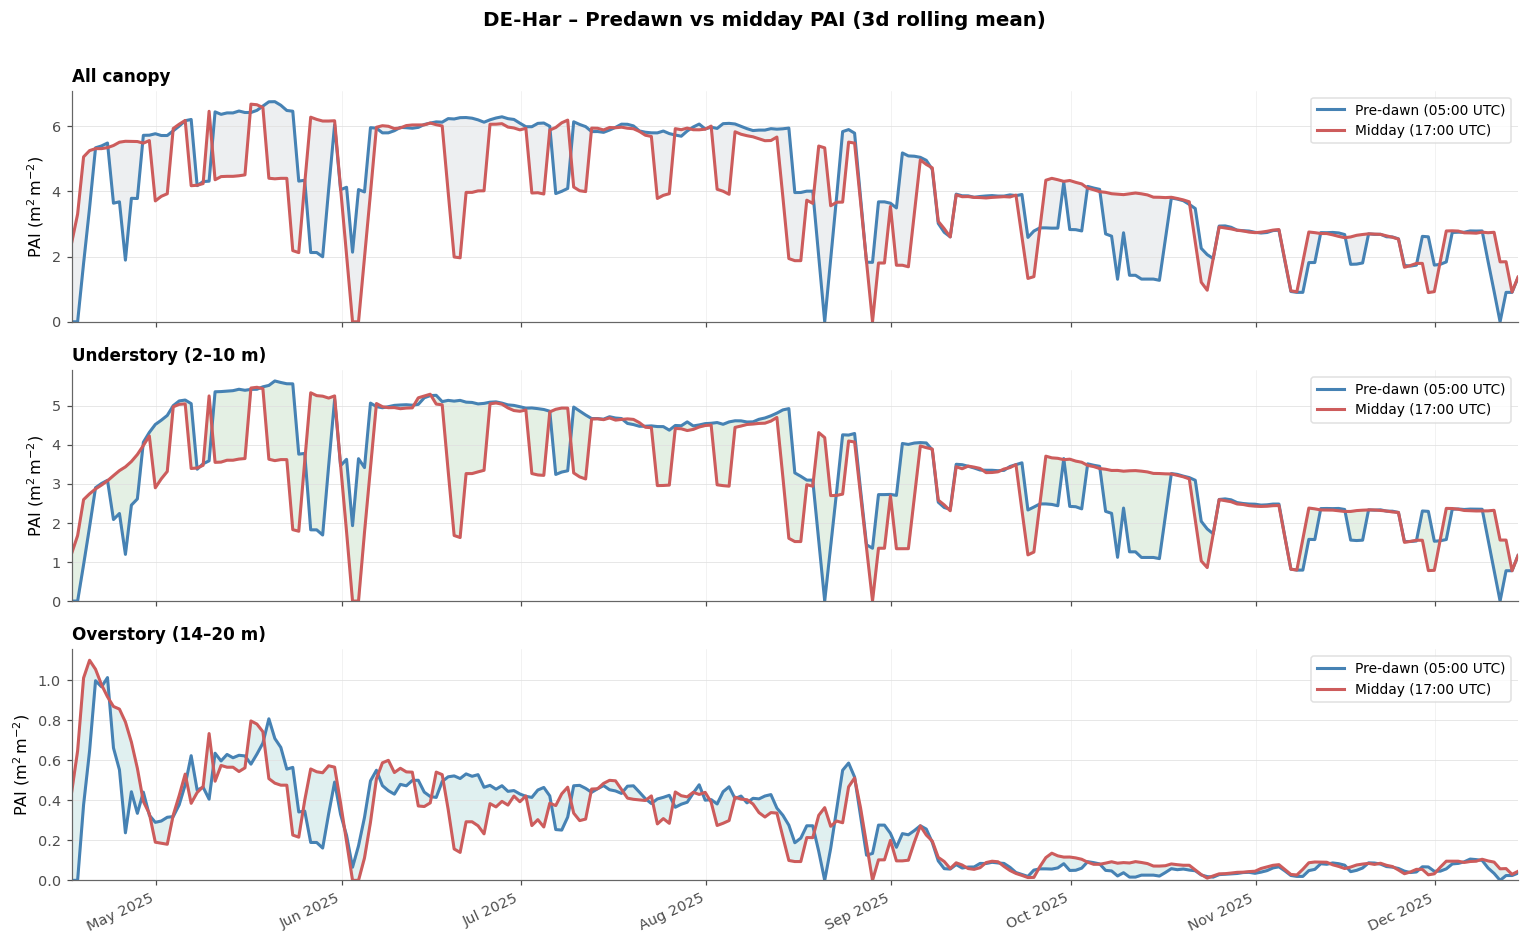

In [68]:
HOUR_PREDAWN = 5
HOUR_MIDDAY = 17
SMOOTH_WIN = 3

if HOUR_PREDAWN not in pavd_grids_by_hour or HOUR_MIDDAY not in pavd_grids_by_hour:
    raise RuntimeError(
        f'Need hours {HOUR_PREDAWN} and {HOUR_MIDDAY} in scan_hours; '
        f'available: {list(pavd_grids_by_hour.keys())}')

def smooth(arr, win=SMOOTH_WIN):
    return pd.Series(arr).rolling(win, center=True, min_periods=1).mean().values

# PAI per 2 m band = mean PAVD in band × band width
pai_pre_2m = pavd_2m_by_hour[HOUR_PREDAWN] * BIN_H
pai_mid_2m = pavd_2m_by_hour[HOUR_MIDDAY]  * BIN_H

# Layer definitions (2 m band indices)
UNDERSTORY = (1, 5)   # bands 1–4 → 2–10 m
OVERSTORY  = (7, 10)  # bands 7–9 → 14–20 m

def layer_pai(arr, lo, hi):
    return np.nansum(arr[lo:hi], axis=0)

panels = [
    ('All canopy',          slice(None), 'slategrey'),
    ('Understory (2\u201310 m)',  slice(*UNDERSTORY), 'forestgreen'),
    ('Overstory (14\u201320 m)', slice(*OVERSTORY),  'darkcyan'),
]

fig, axes = plt.subplots(3, 1, figsize=(14, 8.5), sharex=True)
fig.patch.set_facecolor('white')

for ax, (title, sl, fill_c) in zip(axes, panels):
    pre = smooth(np.nansum(pai_pre_2m[sl], axis=0))
    mid = smooth(np.nansum(pai_mid_2m[sl], axis=0))

    ax.set_facecolor('white')
    ax.plot(leaf_dates, pre, color='steelblue', lw=2,
            label=f'Pre-dawn ({HOUR_PREDAWN:02d}:00 UTC)')
    ax.plot(leaf_dates, mid, color='indianred',  lw=2,
            label=f'Midday ({HOUR_MIDDAY:02d}:00 UTC)')
    ax.fill_between(leaf_dates, pre, mid, color=fill_c, alpha=0.12)

    ax.set_ylabel(r'PAI ($\mathregular{m^2\,m^{-2}}$)', fontsize=10.5)
    ax.set_title(title, fontsize=11, fontweight='bold', loc='left', pad=6)
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=9, loc='upper right', frameon=True,
              edgecolor='0.85', fancybox=True)
    ax.grid(axis='y', color='0.88', lw=0.5)
    ax.grid(axis='x', color='0.92', lw=0.4)
    for sp in ('top', 'right'):
        ax.spines[sp].set_visible(False)
    ax.spines['left'].set_color('0.4')
    ax.spines['bottom'].set_color('0.4')
    ax.tick_params(colors='0.3', labelsize=9.5)

axes[-1].set_xlim(leaf_dates[0], leaf_dates[-1])
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
fig.autofmt_xdate(rotation=25, ha='right')

fig.suptitle(
    f'DE-Har \u2013 Predawn vs midday PAI ({SMOOTH_WIN}d rolling mean)',
    fontsize=13, fontweight='bold', y=1.005)
fig.tight_layout()
plt.show()

---
## 7. Hemispherical projection gallery

Seasonal sequence of hemispherical projections — visual outreach product showing canopy change through the drought. Select one scan per period (pre-stress, HE1, inter-event, HE2, post-stress).

In [30]:
def polar_hemisphere_plot(leaf_file, sensor_height, zenith_offset,
                          ax=None, title='', vmax=20, cmap='bone'):
    """Publication-quality polar hemispherical projection.
    
    Shows range-to-target on a polar plot where:
    - Radius = zenith angle (0° = straight up at center)
    - Angle = azimuth
    - Color = range to first return
    - White = gap (sky)
    """
    f = leaf_io.LeafScanFile(leaf_file, sensor_height=sensor_height,
                              zenith_offset=zenith_offset)
    
    zen_deg = np.degrees(f.data['zenith'].values)
    az_rad = f.data['azimuth'].values  # already in radians
    r1 = f.data['range1'].values.copy()
    
    # Mask gaps
    r1[np.isnan(r1)] = np.nan
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8),
                                subplot_kw={'projection': 'polar'})
    
    sc = ax.scatter(az_rad, zen_deg, c=r1, s=0.3, cmap=cmap,
                    vmin=0, vmax=vmax, alpha=0.6, rasterized=True)
    ax.set_ylim(0, 90)
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)
    ax.set_title(title, pad=15, fontsize=11, fontweight='bold')
    ax.set_yticks([0, 30, 57.5, 90])
    ax.set_yticklabels(['0°', '30°', '57.5°', '90°'], fontsize=7)
    
    return ax, sc

/tmp/ipykernel_1049343/1768632621.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


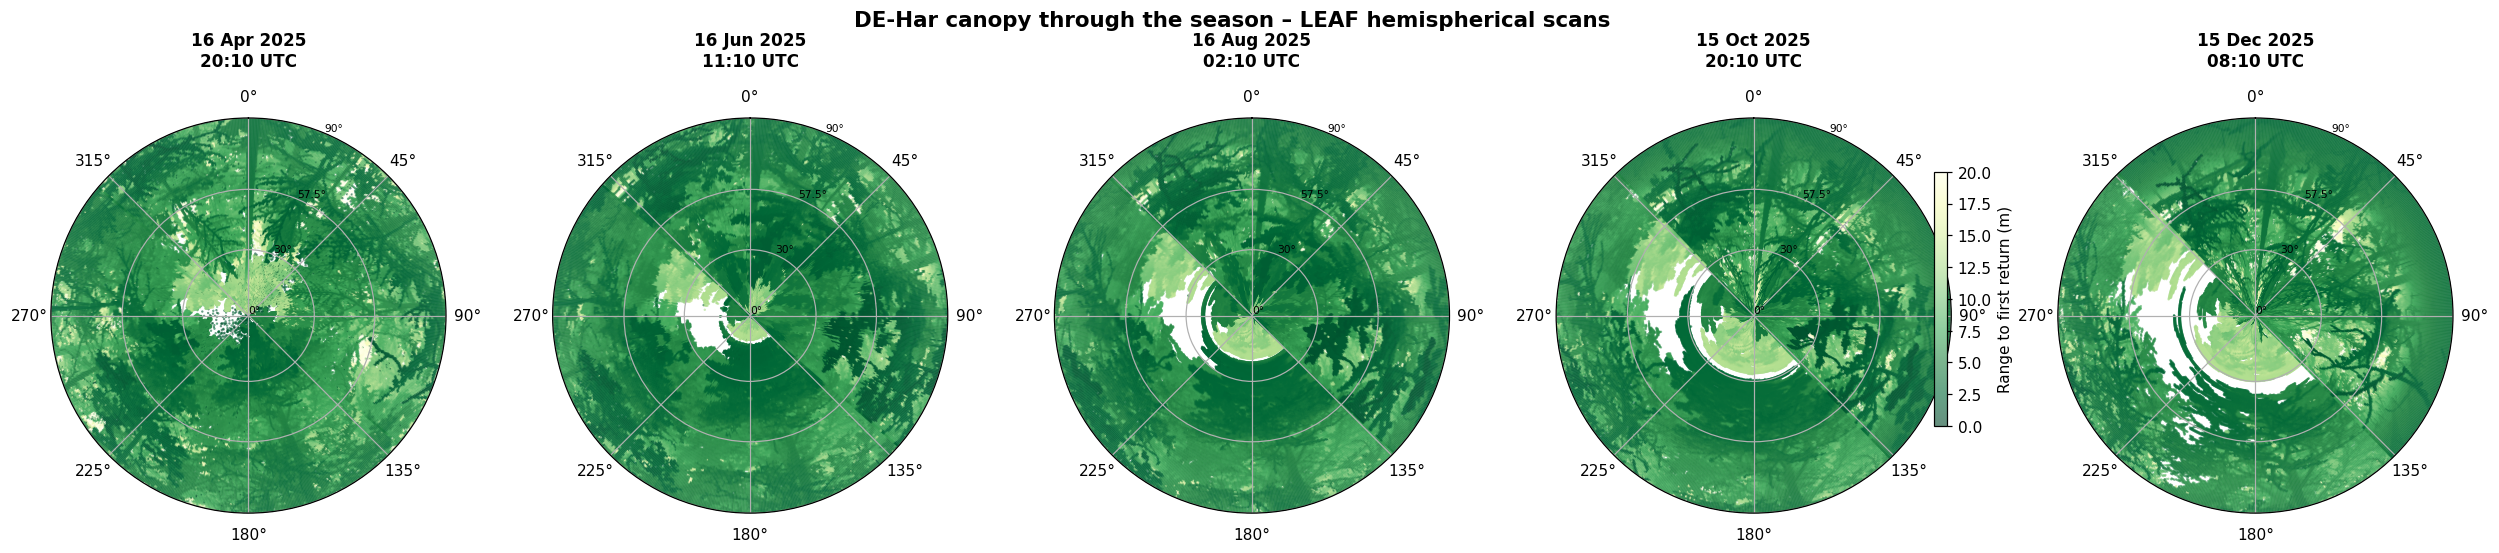

In [31]:
# --- Select representative scans for seasonal gallery ---
# Adjust these indices or filenames to pick scans from key periods
# Example: pick ~5 hemi-hi scans spread across the season

n_hemi = len(hemi_hi_files)
if n_hemi >= 5:
    gallery_indices = [0, n_hemi//4, n_hemi//2, 3*n_hemi//4, n_hemi-1]
else:
    gallery_indices = list(range(n_hemi))

n_panels = len(gallery_indices)
fig, axes = plt.subplots(1, n_panels, figsize=(4.5 * n_panels, 5),
                          subplot_kw={'projection': 'polar'})
if n_panels == 1:
    axes = [axes]

for i, idx in enumerate(gallery_indices):
    fn = str(hemi_hi_files[idx])
    # Extract date from filename for title
    f_tmp = leaf_io.LeafScanFile(fn, sensor_height=SENSOR_HEIGHT,
                                  zenith_offset=ZENITH_OFFSET)
    title = f_tmp.datetime.strftime('%d %b %Y\n%H:%M UTC')
    ax, sc = polar_hemisphere_plot(
        fn, SENSOR_HEIGHT, ZENITH_OFFSET,
        ax=axes[i], title=title, vmax=20, cmap='YlGn_r')

# Shared colorbar
cbar = fig.colorbar(sc, ax=axes, shrink=0.6, pad=0.08,
                     label='Range to first return (m)')

fig.suptitle('DE-Har canopy through the season – LEAF hemispherical scans',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
# plt.savefig('hemisphere_gallery.png', dpi=200, bbox_inches='tight')
plt.show()

---
## 8. Temporal variation in canopy interception

By stacking multiple hemispherical scans, areas of high temporal variability reveal deciduous understory dynamics, while stable areas indicate the evergreen pine overstory. This separation is central to the two-layer canopy argument.

In [ ]:
# Stack a subset of hemi-hi scans (e.g. all nighttime scans)
resolution = 0.48  # slightly coarser than scan for cleaner grid
hemi_subset = hemi_hi_files  # or filter to specific dates
n_stack = len(hemi_subset)

if n_stack > 2:
    sh = (n_stack, int(180 / resolution) + 1, int(360 / resolution) + 1)
    leaf_hemi_stack = np.full(sh, np.nan)
    
    for i, hemi_file in enumerate(hemi_subset):
        g = grid.grid_leaf_spherical(
            str(hemi_file), resolution, attribute='range1',
            method='MIN', sensor_height=SENSOR_HEIGHT,
            transform=False, zenith_offset=ZENITH_OFFSET)
        if g is not None:
            tmp = g[0].astype(float)
            tmp[tmp == -9999] = np.nan
            leaf_hemi_stack[i] = tmp
    
    # Temporal standard deviation
    with np.errstate(all='ignore'):
        std_grid = np.nanstd(leaf_hemi_stack, axis=0, keepdims=True)
    std_grid[np.isnan(std_grid)] = -9999
    
    visualize.plot_leaf_grid(
        std_grid, label=r'$\sigma$ Range (m)', clim=[0, 2],
        figsize=(9, 7), nbins=10, cmap='inferno',
        extent=[0, 360, 180, 0],
        xlabel='Azimuth (°)', ylabel='Zenith (°)',
        facecolor='white',
        title='Temporal variability in canopy interception')
else:
    print('Need >2 hemi-hi scans for temporal analysis')

---
## 9. Export for SPAC cascade analysis

Save the processed time series for integration with SWP, sap flow, VOD, and flux data.

In [ ]:
# Build export DataFrame
export_records = []
for vpp_i in valid_vpp:
    d = vpp_i.datetime
    day = (d - valid_vpp[0].datetime).days
    scan_idx = scan_hours.index(d.hour) if d.hour in scan_hours else -1
    is_good = quality_flags[scan_idx][day] if scan_idx >= 0 else False
    
    pai_z = vpp_i.calcHingePlantProfiles()
    pavd = vpp_i.get_pavd(pai_z)
    
    export_records.append({
        'datetime': d,
        'pai_total': np.max(pai_z),
        'pai_overstory': np.sum(pavd[overstory_bins]) * HRES,
        'pai_understory': np.sum(pavd[understory_bins]) * HRES,
        'quality': is_good,
        'scan_hour': d.hour,
    })

df_export = pd.DataFrame(export_records).set_index('datetime')
# df_export.to_csv('leaf_pai_timeseries_dehar.csv')
display(df_export.head(10))
print(f'\n{df_export.quality.sum()}/{len(df_export)} quality-flagged observations')

---
## Notes

### Parameters to verify
- **`SENSOR_HEIGHT`**: Measure in field — distance from LEAF scan head to ground surface
- **`ZENITH_OFFSET`**: Check first scan visually; adjust if hinge angle is not at 57.5°. Units: radians
- **Tilt correction**: `leaf_io` applies tilt from header by default (`transform=True`). If tilt sensor is unreliable, set `transform=False` in `grid_leaf_spherical` and `LeafScanFile`
- **Firmware version**: MkIII with firmware ≥ 4.11 uses 25,600 encoder steps (8 columns incl. intensity2). Older firmware uses 10,000 steps (7 columns). `leaf_io` handles this automatically.

### Key differences from custom pipeline
- `leaf_io` handles: encoder → angle conversion, tilt correction, hemi azimuth flipping, target counting
- `plant_profile.Jupp2009` handles: Pgap binning by zenith/azimuth/height, three PAI methods, PAVD
- `rsmooth` handles: quality filtering via robust smoothing with bisquare weights

### Downstream integration
- **VOD structural correction**: regress GNSS-T nVOD against LEAF PAI to isolate water content
- **PELT changepoints**: run on height-integrated PAI time series, aligned with SWP threshold crossings
- **Satellite validation**: LEAF PAVD profiles serve as ground truth for Sentinel-1/2 pixel-level comparison